# 4 Data analysis

## Setup

### Load libraries

In [9]:
library(tidyverse)
library(RColorBrewer)
library(svglite)

options(warn = -1)

### Set working directory

In [ ]:
wd <- "/path/to/05_analysis/01_macropinocytosis_quantification"

### Load data

In [ ]:
data_path <- file.path(wd, "02_data", "mpc_quantification.csv")
data.raw <- read.csv(data_path, sep = ",")

## 2 Data processing and stats

### Extract relavant columns and rows from raw data
Parse metadata from filenames, exclude second knockout strain, and filter cell size.


In [10]:
data.cleanup <- data.raw 
data.cleanup <- data.cleanup %>% separate(datafile, into = c("experiment", "time" ,"strain", "well", "region"), sep = "_", remove = T)
data <- data.cleanup %>% filter(strain != "d6") %>% filter(strain != "r6") %>% filter(cell_area <= 6000)  

### Calculate MPCI per cell
Macropinocytic Index (MPCI) quantifies the proportion of cell area occupied by dextran-positive compartments during a defined uptake period.


In [12]:
data <- data %>%
  mutate(mpci = mpc_area / cell_area)

### Summarize experiment-level means and standard errors
Group by experiment, strain, and time; compute mean and SE for all relevant metrics.


In [13]:
# Columns to exclude from summarization (including identifiers and grouping variables)
exceptions <- c("datafile", "id", "experiment", "strain", "time", "well", "region")

# Target columns for numeric summarization
columns_to_summarize <- setdiff(colnames(data), exceptions)

data.summary.experiments <- data %>%
  group_by(experiment, strain, time) %>%
  summarise(
    n = n(),
    across(
      .cols = all_of(columns_to_summarize),
      .fns = list(
        mean = ~mean(.x, na.rm = TRUE),
        se = ~sd(.x, na.rm = TRUE) / sqrt(n())
      ),
      .names = "{.col}.{.fn}"
    ),
    .groups = "drop"
  )


### Perform ANOVA across experimental replicates
Test for differences between experiments within each strain and timepoint.


In [14]:
# Fit two-way ANOVA model with interaction
anova_model <- aov(mpci.mean ~ strain * time, data = data.summary.experiments)
summary(anova_model)

# Tukey post hoc test for strain:time interaction
tukey_test <- TukeyHSD(anova_model)
tukey_results <- tukey_test$`strain:time`

# Parse Tukey results
tukey_results <- data.frame(Comparison = rownames(tukey_results), tukey_results)
row.names(tukey_results) <- NULL

tukey_results <- tukey_results %>%
  separate(Comparison, into = c("g1", "t1", "g2", "t2"), sep = "[-:]") %>%
  mutate(significance = case_when(
    p.adj < 0.001 ~ "***",
    p.adj < 0.01  ~ "**",
    p.adj < 0.05  ~ "*",
    TRUE          ~ ""
  ))

# Extract significant within-timepoint comparisons
tukey_results_sig <- tukey_results %>%
  filter(t1 == t2, p.adj <= 0.05)


            Df Sum Sq Mean Sq F value   Pr(>F)    
strain       2 0.4012 0.20062  52.054 3.29e-08 ***
time         2 0.0220 0.01100   2.855   0.0838 .  
strain:time  4 0.0188 0.00469   1.217   0.3383    
Residuals   18 0.0694 0.00385                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Visualization
Visualize MPCI per strain and timepoint with Tukey significance markers.
Therefore, create bar plot with statistical annotations and save as SVG.


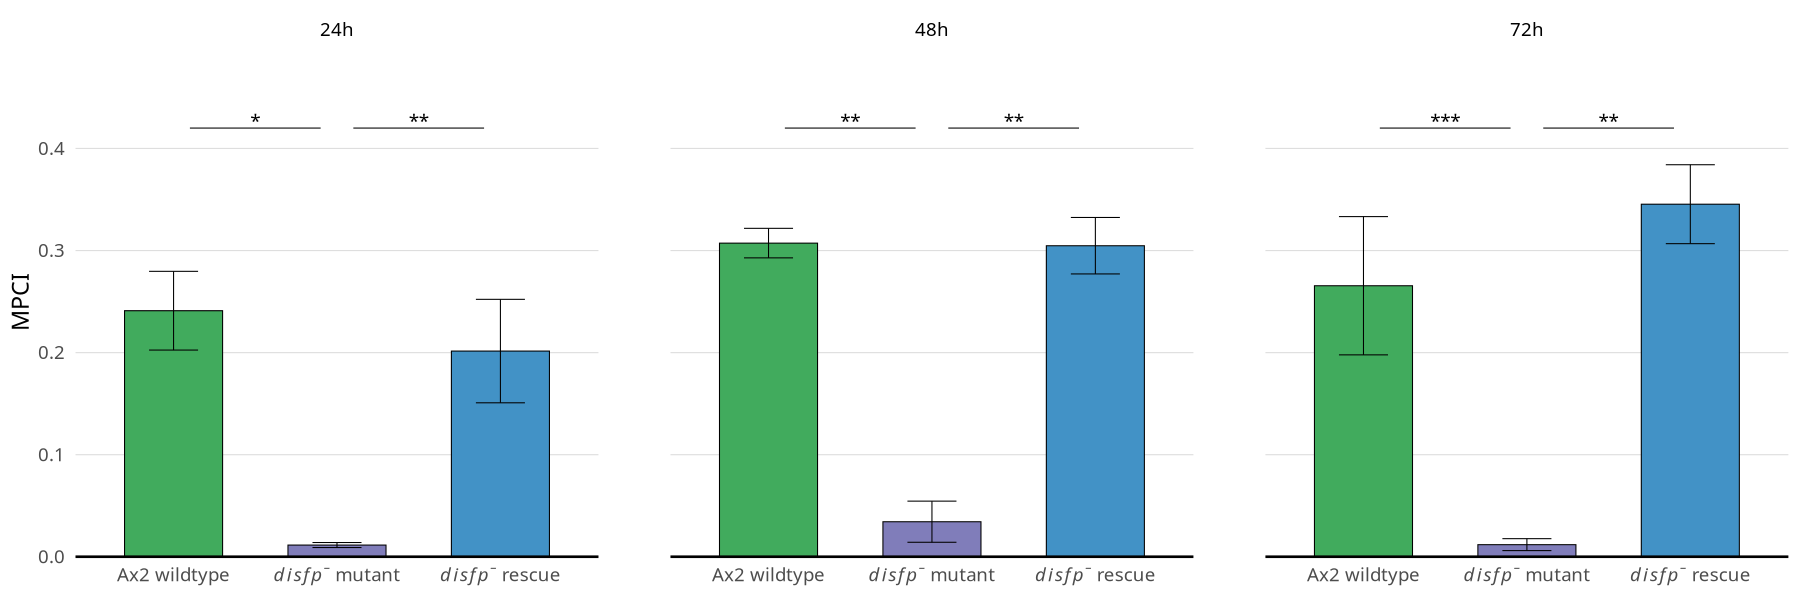

In [ ]:
# Significance bar annotations
y_sigline <- 0.42
annotations <- data.frame(
  time = c("t0", "t0", "t1", "t1", "t2", "t2"),
  x_min = c(1.1, 2.1, 1.1, 2.1, 1.1, 2.1),
  x_max = c(1.9, 2.9, 1.9, 2.9, 1.9, 2.9),
  y = rep(y_sigline, 6),
  label = tukey_results_sig$significance
)

# Colors for strains
wt_colors <- brewer.pal(9, "Greens")
disfp_colors <- brewer.pal(9, "Purples")
rescue_colors <- brewer.pal(9, "Blues")
color_nr <- 6
strain_colors <- c("wt" = wt_colors[color_nr], "d3" = disfp_colors[color_nr], "r3" = rescue_colors[color_nr])

# Strain display labels
strain_rename <- c(
  "d3" = expression(italic(disfp^"–")*" mutant"),
  "r3" = expression(italic(disfp^"–")*" rescue"),
  "wt" = expression("Ax2 wildtype")
)

# Strain order
strain_levels <- c("wt", "d3", "r3")

# Timepoint labels
rename_time <- list("t0" = "24h", "t1" = "48h", "t2" = "72h")
labeller_time <- function(variable, value) rename_time[value]

# Prepare plotting data
data.summary.experiments.plot <- data.summary.experiments %>%
  filter(strain %in% strain_levels) %>%
  mutate(strain = factor(strain, levels = strain_levels))

# Compute group-wise means and SE
summary_data <- data.summary.experiments.plot %>%
  group_by(strain, time) %>%
  summarise(
    mpc_mean = mean(mpci.mean, na.rm = TRUE),
    mpc_se = sd(mpci.mean, na.rm = TRUE) / sqrt(n()),
    .groups = 'drop'
  )

# Plot
mpca_bar_plot_transparent <- ggplot(summary_data, aes(x = strain, y = mpc_mean, fill = strain)) +
  geom_col(position = position_dodge(), width = 0.6, color = "black", size = 0.3) +
  geom_errorbar(aes(ymin = mpc_mean - mpc_se, ymax = mpc_mean + mpc_se), width = .3, position = position_dodge(0.5), size = 0.3) +
  facet_wrap(~time, labeller = labeller_time) +
  scale_fill_manual(values = strain_colors) +
  geom_segment(data = annotations, aes(x = x_min, xend = x_max, y = y, yend = y), inherit.aes = FALSE, color = "black", size = 0.3) +
  geom_text(data = annotations, aes(x = (x_min + x_max) / 2, y = y, label = label), inherit.aes = FALSE, vjust = -0.025, size = 4) +
  scale_x_discrete(labels = strain_rename) +
  labs(x = NULL, y = "MPCI") +
  scale_y_continuous(expand = expansion(mult = c(0, 0)), limits = c(0, 0.499)) +
  theme_light(base_size = 14) +
  theme(
    panel.border = element_blank(),
    panel.spacing = unit(3, "lines"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line.x = element_line(color = "black", size = 0.75),
    axis.ticks = element_blank(),
    strip.text.x = element_text(color = "black"),
    strip.background = element_rect(fill = "transparent", color = NA),
    plot.background = element_rect(fill = "transparent", color = NA),
    panel.background = element_rect(fill = "transparent", color = NA),
    legend.background = element_rect(fill = "transparent", color = NA),
    legend.key = element_rect(fill = "transparent", color = NA)
  ) +
  guides(fill = FALSE)

# Show the plot
mpca_bar_plot_transparent

# Theme for export (optional styling)
custom_theme <- theme_minimal(base_size = 8) +
  theme(
    axis.title = element_text(face = "bold", size = 8),
    axis.text = element_text(size = 8, color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 6),
    panel.border = element_blank(),
    panel.spacing = unit(0.5, "lines"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    panel.grid.major.y = element_line(color = "grey75", size = 0.15),
    axis.line.x = element_line(color = "black", size = 0.25),
    axis.ticks = element_blank(),
    strip.text = element_text(face = "bold", size = 8),
    legend.position = "none"
  )

# Save SVG
results_img_dir <- file.path(wd, "results", "img")
if (!dir.exists(results_img_dir)) dir.create(results_img_dir, recursive = TRUE)

save_path <- file.path(results_img_dir, "mpca_bar_plot_transparent.svg")
ggsave(
  save_path,
  plot = mpca_bar_plot_transparent + custom_theme,
  width = 87 / 25.4, height = 45 / 25.4,
  units = "in", bg = "transparent", device = svglite
)
